In [1]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import xarray as xr
from pymc_marketing.metrics import crps
from sklearn.metrics import mean_absolute_error as mae

az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [10, 6]
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"

%load_ext autoreload
%autoreload 2
%load_ext jaxtyping
%jaxtyping.typechecker beartype.beartype
%config InlineBackend.figure_format = "retina"

/Users/juanitorduz/Documents/website_projects/.pixi/envs/default/lib/python3.13/site-packages/sympy/external/gmpy.py:139: UserWarning: gmpy2 version is too old to use (2.0.0 or newer required)
  gmpy = import_module('gmpy2', min_module_version=_GMPY2_MIN_VERSION,
/Users/juanitorduz/Documents/website_projects/.pixi/envs/default/lib/python3.13/site-packages/pymc_marketing/pytensor_utils.py:34: FutureWarning: `pytensor.graph.basic.ancestors` was moved to `pytensor.graph.traversal.ancestors`. Calling it from the old location will fail in a future release.
  from pytensor.graph.basic import ancestors


In [2]:
seed: int = 42
rng: np.random.Generator = np.random.default_rng(seed=seed)

n = 50

y_true = rng.normal(0, 1, size=n)

draws = 1_000
k = 21

mus = np.linspace(-10, 10, k)
sigmas = np.linspace(0.1, 10, k)

noise = rng.normal(0, 1, size=(1, draws, n))

sigma = sigmas[np.newaxis, np.newaxis, :] * noise[..., np.newaxis]

y_pred_array = (
    y_true[np.newaxis, np.newaxis, :, np.newaxis, np.newaxis]
    + mus[np.newaxis, np.newaxis, np.newaxis, np.newaxis, :]
    + sigma[..., np.newaxis]
)

y_pred = xr.DataArray(
    y_pred_array,
    coords=([0], np.arange(draws), np.arange(n), sigmas, mus),
    dims=["chain", "draw", "n", "sigma", "mu"],
)

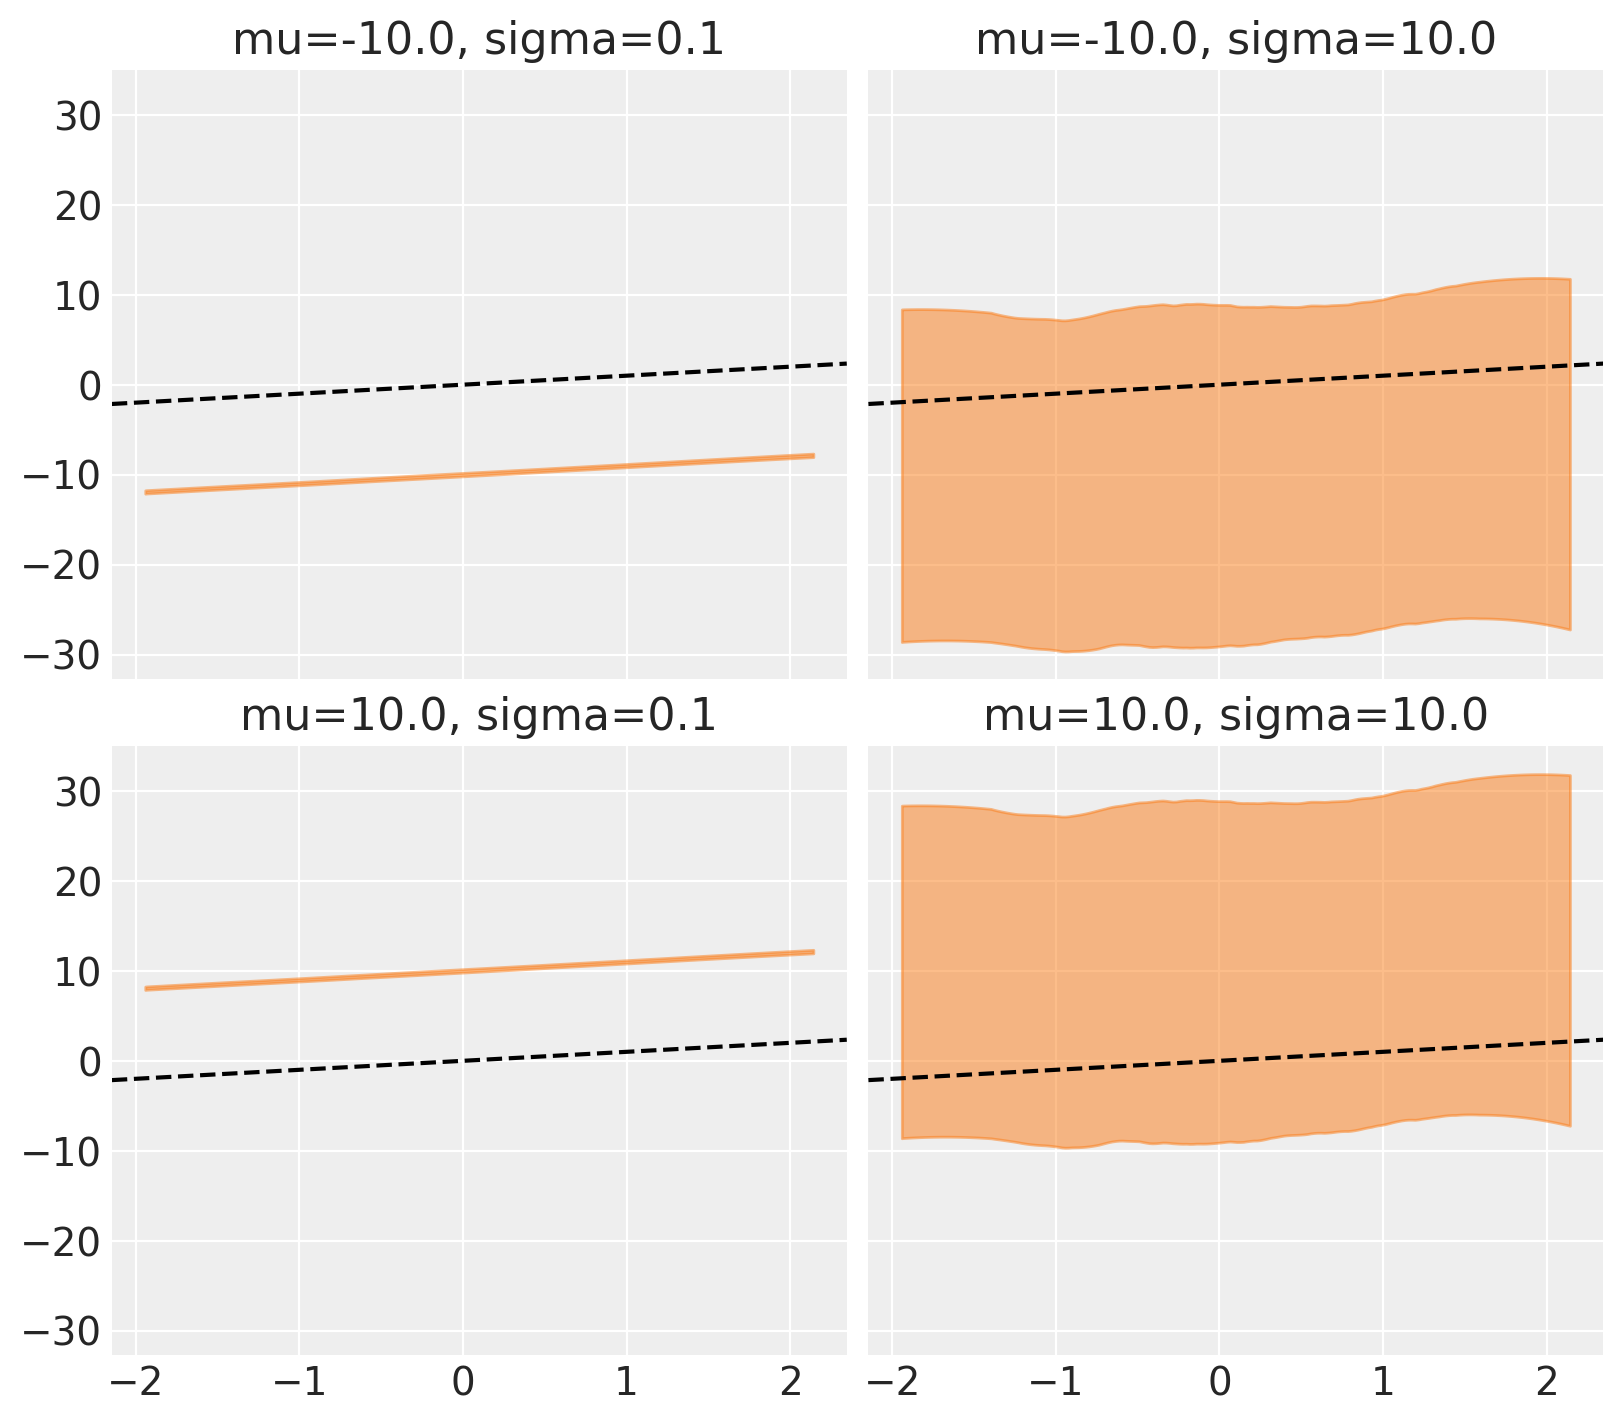

In [3]:
fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(8, 7),
    sharex=True,
    sharey=True,
    layout="constrained",
)

_y_pred = y_pred.sel(mu=mus[0], sigma=sigmas[0])
az.plot_hdi(y_true, _y_pred, ax=axes[0, 0])
axes[0, 0].axline((0, 0), slope=1, color="black", linestyle="--")
axes[0, 0].set_title(f"mu={mus[0]:.1f}, sigma={sigmas[0]:.1f}")

_y_pred = y_pred.sel(mu=mus[0], sigma=sigmas[-1])
az.plot_hdi(y_true, _y_pred, ax=axes[0, 1])
axes[0, 1].axline((0, 0), slope=1, color="black", linestyle="--")
axes[0, 1].set_title(f"mu={mus[0]:.1f}, sigma={sigmas[-1]:.1f}")

_y_pred = y_pred.sel(mu=mus[-1], sigma=sigmas[0])
az.plot_hdi(y_true, _y_pred, ax=axes[1, 0])
axes[1, 0].axline((0, 0), slope=1, color="black", linestyle="--")
axes[1, 0].set_title(f"mu={mus[-1]:.1f}, sigma={sigmas[0]:.1f}")

_y_pred = y_pred.sel(mu=mus[-1], sigma=sigmas[-1])
az.plot_hdi(y_true, _y_pred, ax=axes[1, 1])
axes[1, 1].axline((0, 0), slope=1, color="black", linestyle="--")
axes[1, 1].set_title(f"mu={mus[-1]:.1f}, sigma={sigmas[-1]:.1f}");

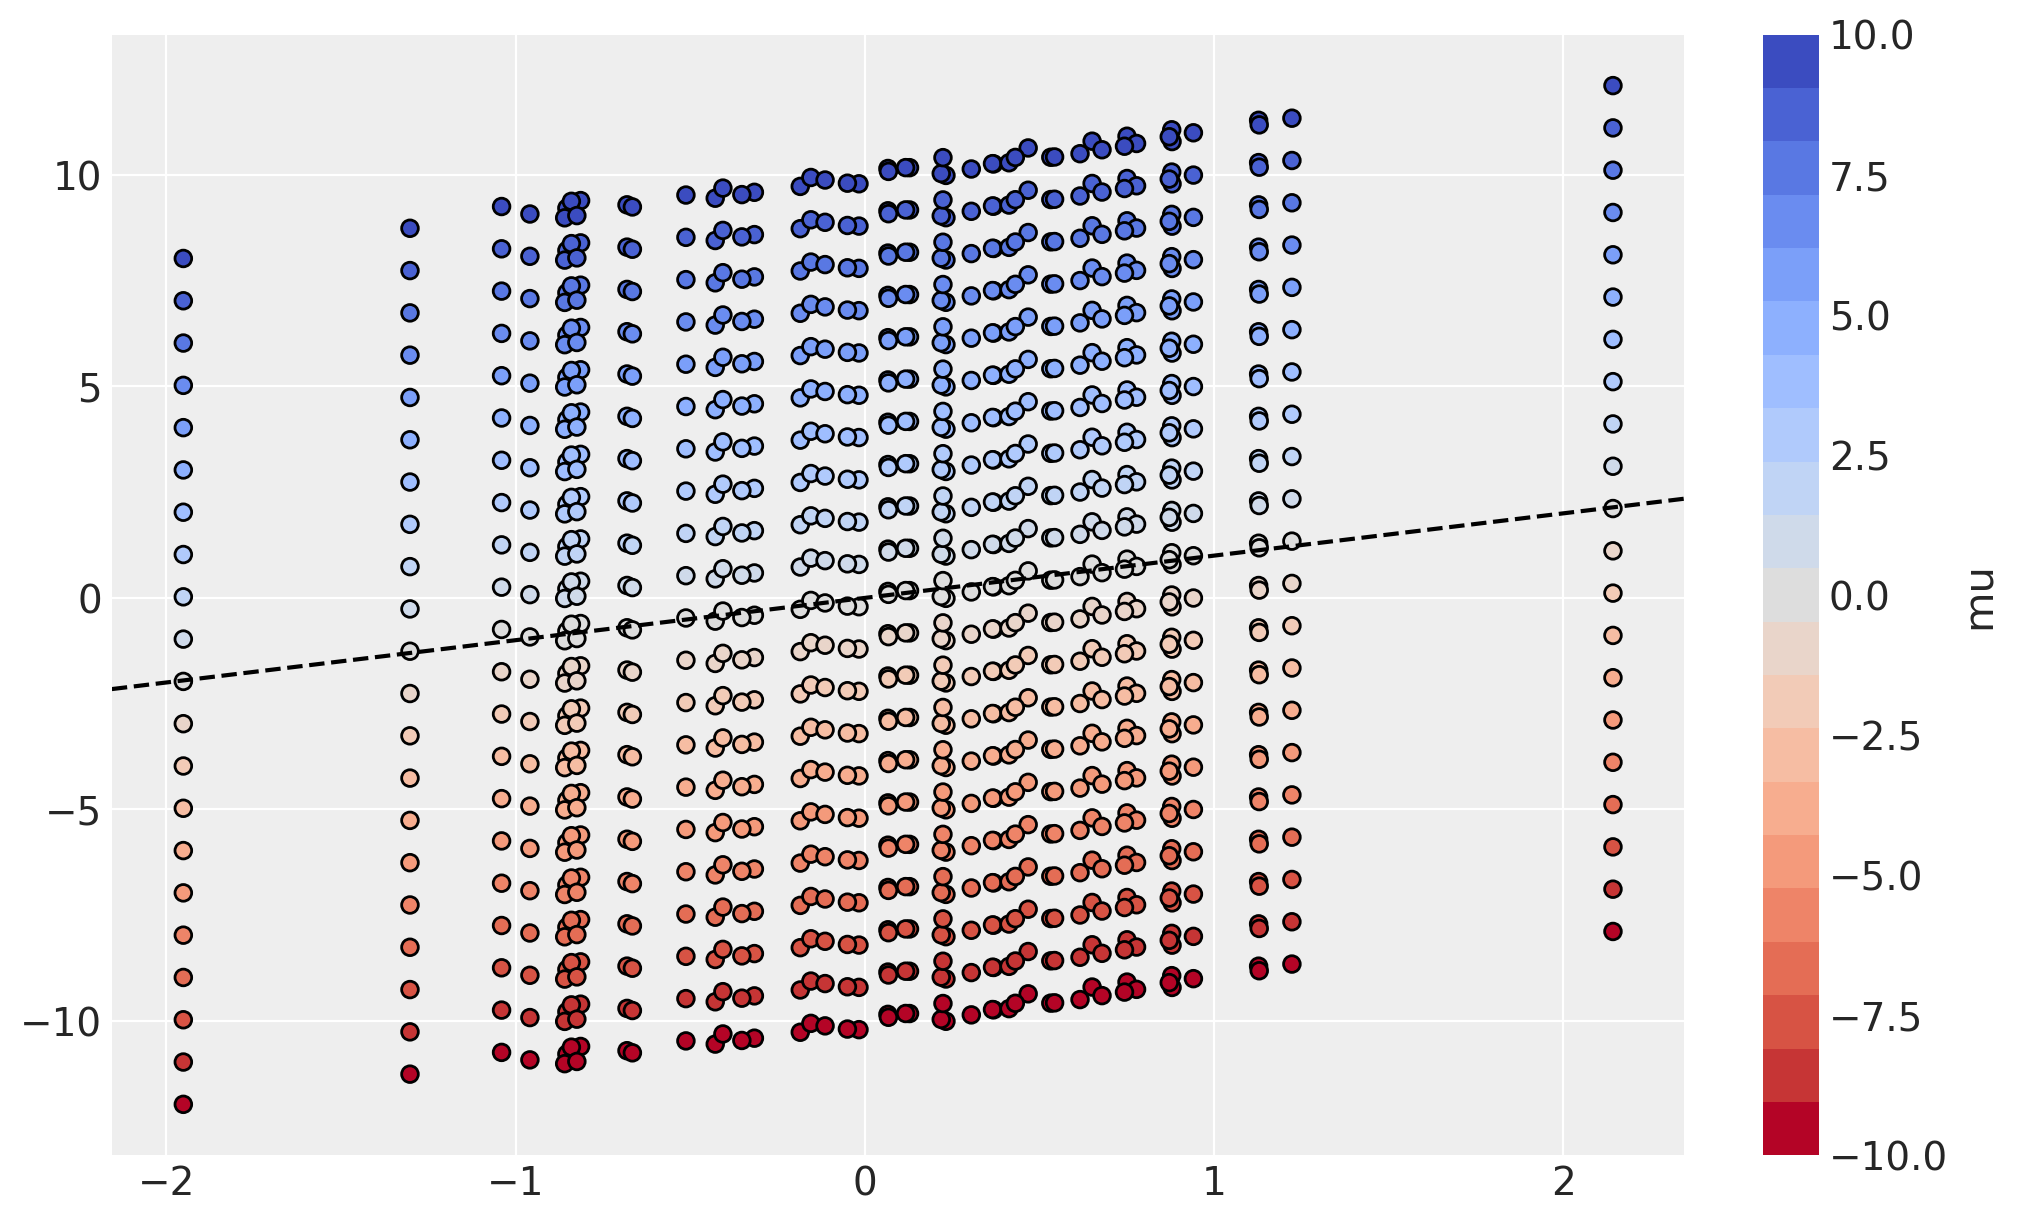

In [4]:
y_pred.sel(mu=0).mean(dim=("chain", "draw", "sigma"))

cmap = plt.get_cmap("coolwarm_r", k)

fig, ax = plt.subplots(figsize=(10, 6))

sc = None
for mu in mus:
    _y_pred_mean = y_pred.sel(mu=mu).mean(dim=("chain", "draw", "sigma"))
    sc = ax.scatter(
        y_true,
        _y_pred_mean,
        edgecolor="black",
        label=f"mu={mu:.2f}",
        c=[mu] * len(y_true),
        vmin=mus[0],
        vmax=mus[-1],
        cmap=cmap,
    )

cbar = plt.colorbar(sc, ax=ax, orientation="vertical", label="mu")
ax.axline((0, 0), slope=1, color="black", linestyle="--")

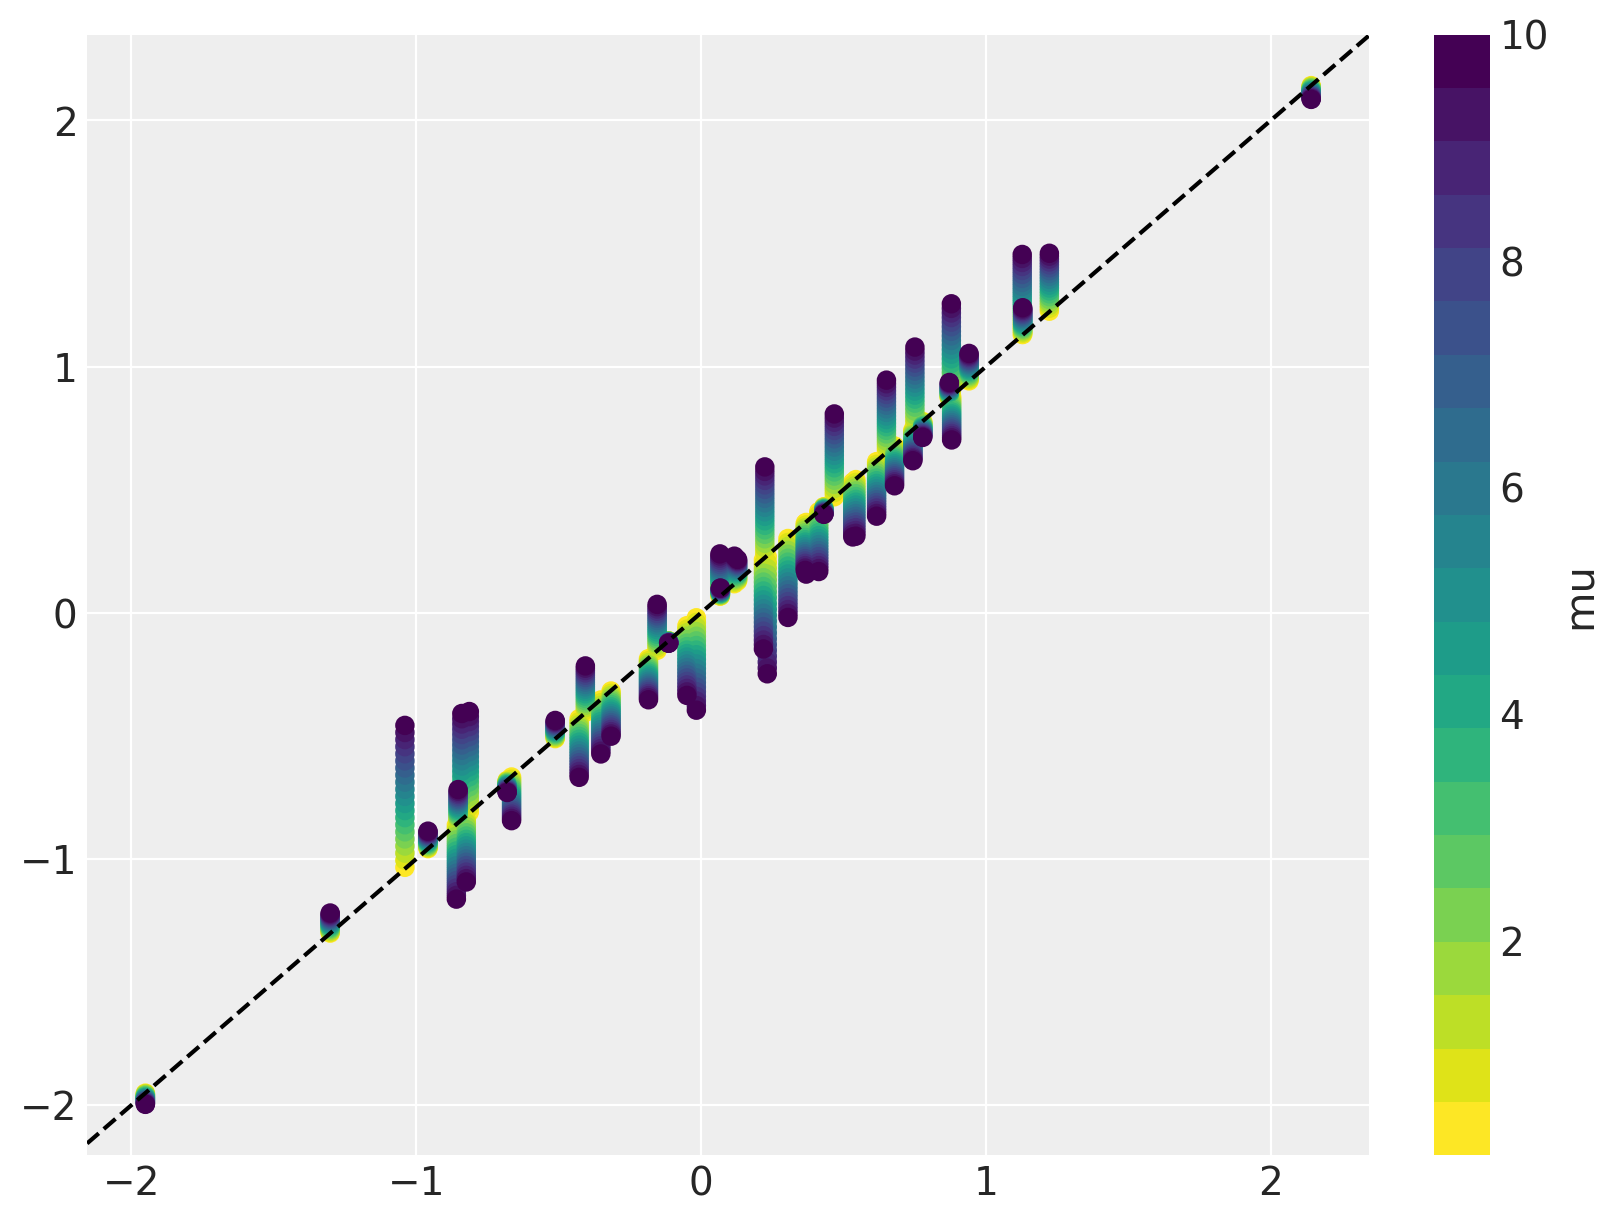

In [5]:
y_pred.sel(mu=0).mean(dim=("chain", "draw", "sigma"))

cmap = plt.get_cmap("viridis_r", k)

fig, ax = plt.subplots(figsize=(8, 6))

sc = None
for sigma in sigmas:
    _y_pred_mean = y_pred.sel(sigma=sigma).mean(dim=("chain", "draw", "mu"))
    sc = ax.scatter(
        y_true,
        _y_pred_mean,
        label=f"sigma={sigma:.2f}",
        c=[sigma] * len(y_true),
        vmin=sigmas[0],
        vmax=sigmas[-1],
        cmap=cmap,
    )

cbar = plt.colorbar(sc, ax=ax, orientation="vertical", label="mu")
ax.axline((0, 0), slope=1, color="black", linestyle="--")

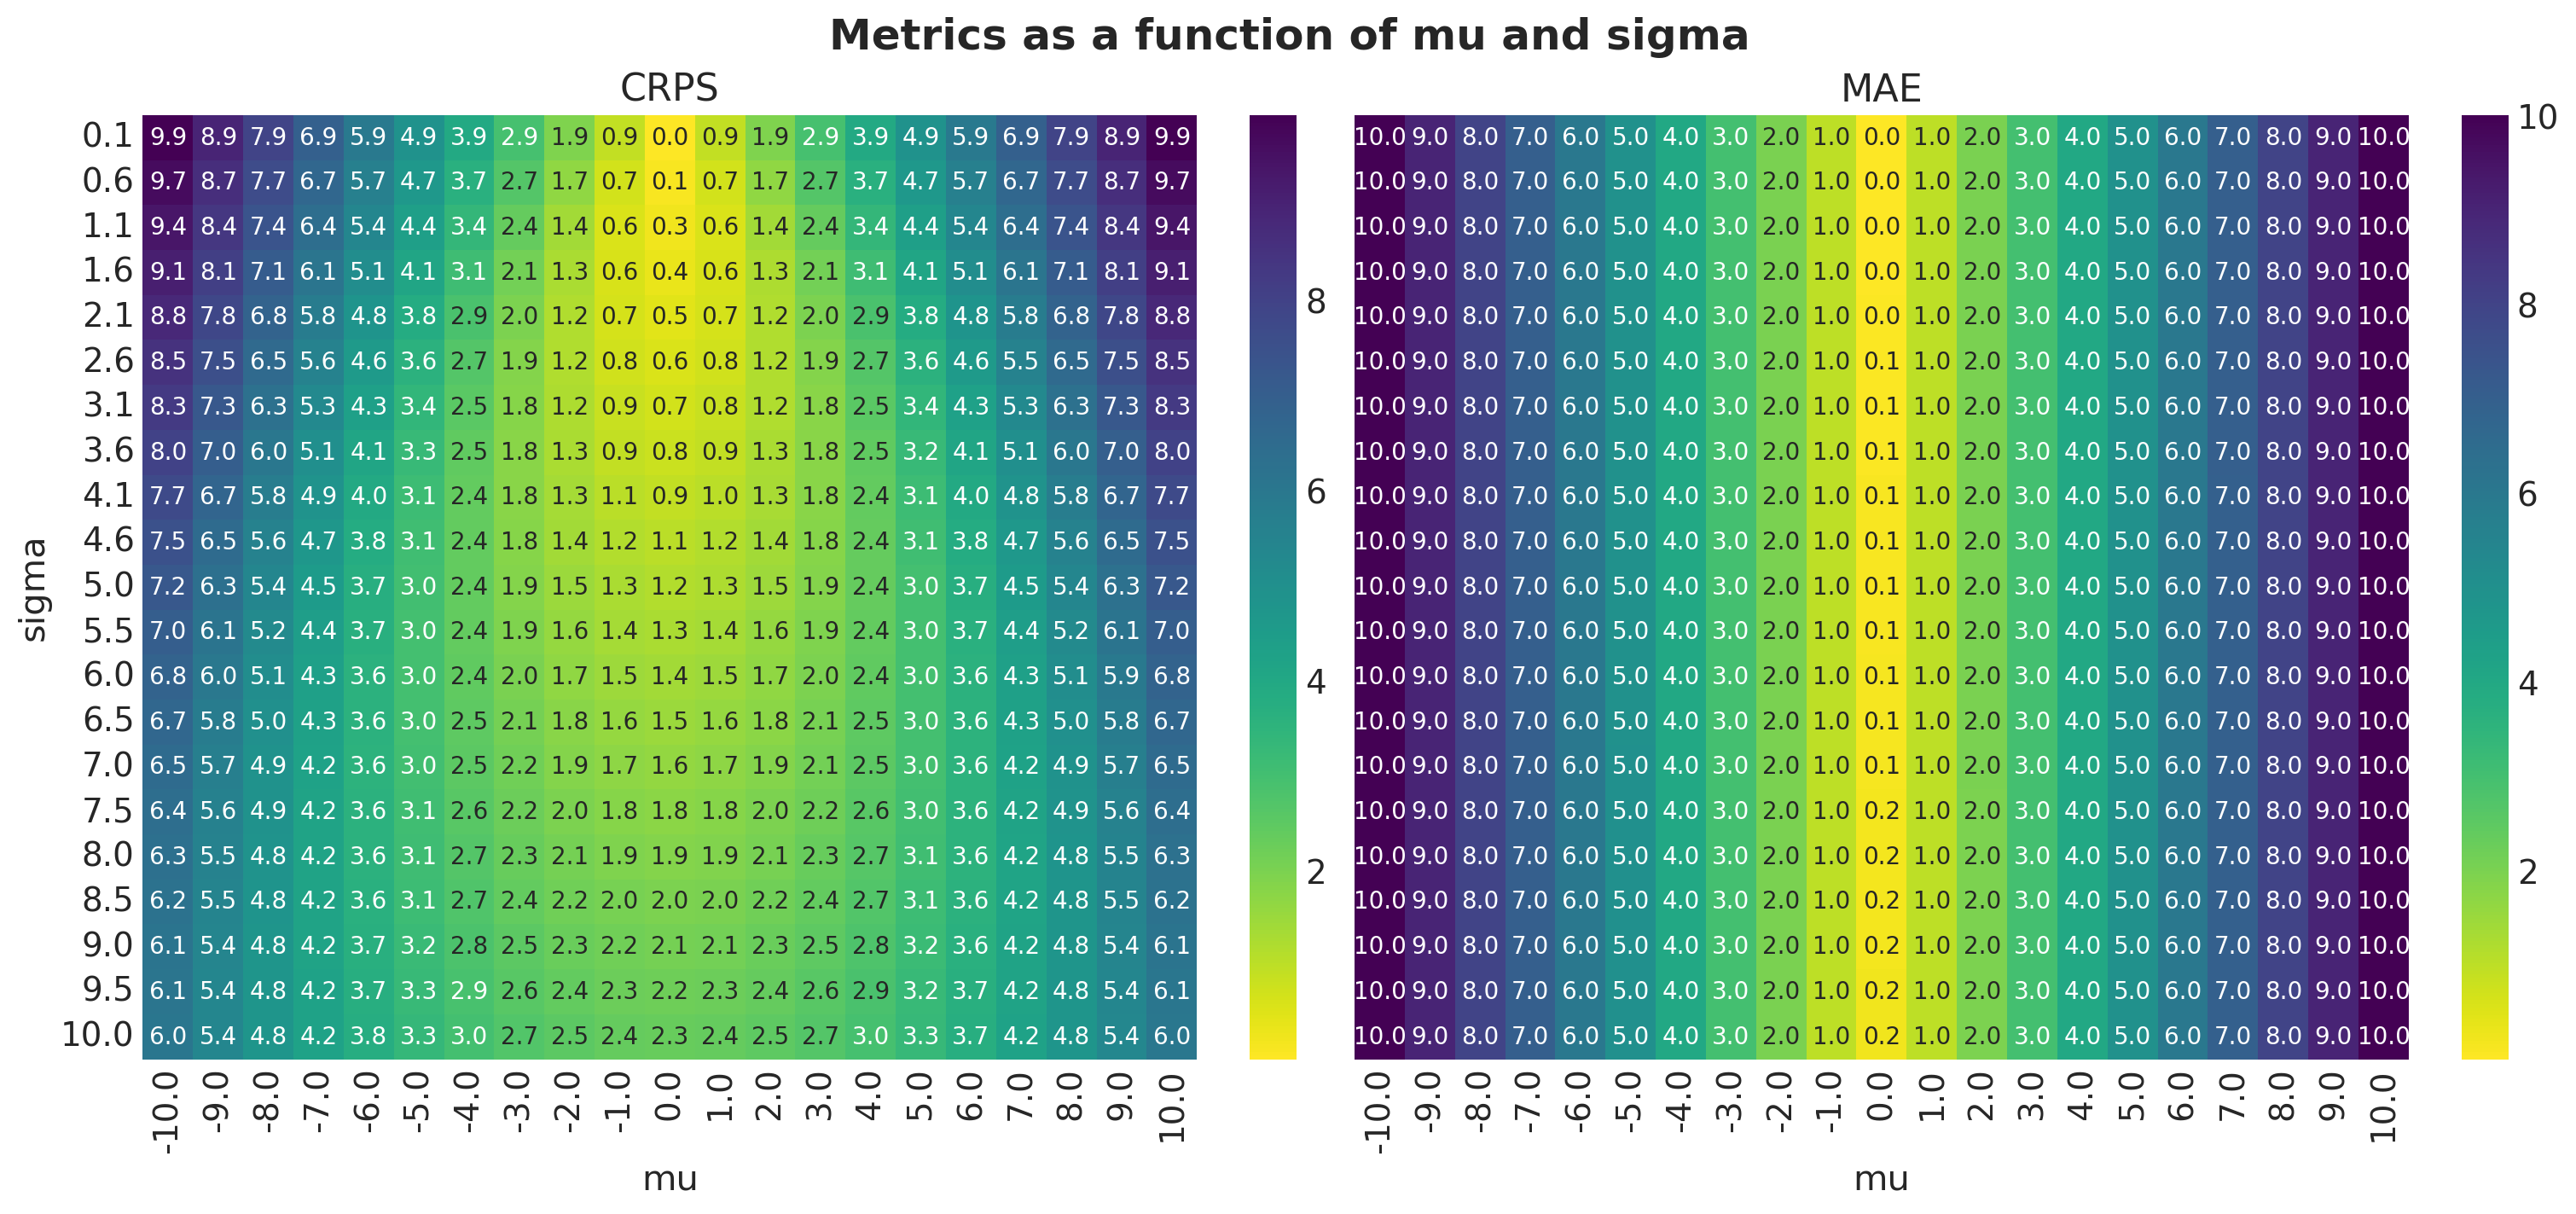

In [6]:
crps_values = np.empty((len(mus), len(sigmas)))
maes_values = np.empty((len(mus), len(sigmas)))

for i, sigma in enumerate(sigmas):
    for j, mu in enumerate(mus):
        _y_pred = y_pred.sel(chain=0, sigma=sigma, mu=mu)
        crps_values[i, j] = crps(y_true, _y_pred)
        maes_values[i, j] = mae(y_true, _y_pred.mean(dim=("draw")))

fig, ax = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(15, 7),
    sharex=True,
    sharey=True,
    layout="constrained",
)

sns.heatmap(
    crps_values,
    cmap="viridis_r",
    annot=True,
    fmt=".1f",
    xticklabels=[f"{mu:.1f}" for mu in mus],
    yticklabels=[f"{sigma:.1f}" for sigma in sigmas],
    ax=ax[0],
)
ax[0].set(title="CRPS", xlabel="mu", ylabel="sigma")

sns.heatmap(
    maes_values,
    cmap="viridis_r",
    annot=True,
    fmt=".1f",
    xticklabels=[f"{mu:.1f}" for mu in mus],
    yticklabels=[f"{sigma:.1f}" for sigma in sigmas],
    ax=ax[1],
)
ax[1].set(title="MAE", xlabel="mu")

fig.suptitle("Metrics as a function of mu and sigma", fontsize=18, fontweight="bold");